In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ============================================================
# 1. Load data
# ============================================================

df = pd.read_excel("Winery_Data_Students.xlsx")

# Add a Year column from Date
df["Year"] = df["Date"].dt.year

print("Total rows (order-level):", df.shape[0])
print(df["Year"].value_counts().sort_index())

# ============================================================
# 2. Split orders into pre-2010 and 2010
#    Pre-2010 (2008–2009) -> features
#    2010 -> target (future)
# ============================================================
pre = df[df["Year"] <= 2009].copy()
yr2010 = df[df["Year"] == 2010].copy()

print("\nPre-2010 orders:", pre.shape[0])
print("2010 orders:", yr2010.shape[0])

# ============================================================
# 3. Build CUSTOMER-LEVEL features from pre-2010 data
#    One row per customer, using only information available
#    by end of 2009.
# ============================================================
agg_features = {
    "Customer Segment": "first",
    "Zip Code": "first",
    "State": "first",
    "Year Acquired": "first",
    "Sales 2008": "first",
    "Sales 2009": "first",
    "Orders 2008": "first",
    "Orders 2009": "first",
    # engagement / channels pre-2010
    "Email Subscr": "max",          # ever subscribed up to 2009
    "Newsletter Subscr": "max",     # ever subscribed up to 2009
    "Email Sales": "sum",           # total pre-2010
    "Newsletter Sales": "sum",
    "Tasting Room Sales": "sum",
}

cust_pre = pre.groupby("Customer ID").agg(agg_features)
print("\nCustomers with pre-2010 history:", cust_pre.shape[0])

# ============================================================
# 4. Build target: did they buy via Winemaker Call in 2010?
# ============================================================
wm_2010 = (
    yr2010
    .groupby("Customer ID")["Winemaker Call Sales"]
    .sum()
    .rename("wmcall_2010")
)

# Join target onto pre-2010 customers; missing -> 0
data = cust_pre.join(wm_2010, how="left")
data["wmcall_2010"] = data["wmcall_2010"].fillna(0)

# Binary target: any Winemaker Call Sales in 2010?
data["target_win_2010"] = (data["wmcall_2010"] > 0).astype(int)

print("\nCustomer-level rows (model population):", data.shape[0])
num_buyers = int(data["target_win_2010"].sum())
base_rate = data["target_win_2010"].mean()
print("Customers with Winemaker Call purchases in 2010:", num_buyers)
print("Base rate (buyers / all customers):", round(base_rate, 4))

# ============================================================
# 5. Define features (X) and target (y)
#    IMPORTANT: no 2010 info, no Winemaker Call fields in X.
# ============================================================
cat_features = ["Customer Segment", "State"]
num_features = [
    "Zip Code",
    "Year Acquired",
    "Sales 2008", "Sales 2009",
    "Orders 2008", "Orders 2009",
    "Email Subscr", "Newsletter Subscr",
    "Email Sales", "Newsletter Sales", "Tasting Room Sales",
]

X = data[cat_features + num_features].copy()
y = data["target_win_2010"].copy()

# ============================================================
# 6. Preprocessing + Logistic Regression model
# ============================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # deal with rare buyers
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg),
])

# ============================================================
# 7. Train / Test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ============================================================
# 8. Fit model
# ============================================================
clf.fit(X_train, y_train)

# ============================================================
# 9. Evaluate model (AUC, confusion, report)
# ============================================================
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=3)

print("\n================ MODEL PERFORMANCE ================")
print("ROC AUC:", round(roc_auc, 3))
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(cm)
print("\nClassification report:")
print(report)

# ============================================================
# 10. Lift analysis: how good is the ranking for targeting?
# ============================================================
test_df = pd.DataFrame({"proba": y_proba, "y": y_test.values})
test_df_sorted = test_df.sort_values("proba", ascending=False).reset_index(drop=True)
base_rate_test = y_test.mean()

print("\nBase Winemaker-Call buyer rate in TEST set:", round(base_rate_test, 4))
print("\n=== Lift vs base rate at different target sizes ===")
total_positives = test_df_sorted["y"].sum()

for frac in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(len(test_df_sorted) * frac))
    subset = test_df_sorted.iloc[:k]
    rate = subset["y"].mean()
    lift = rate / base_rate_test if base_rate_test > 0 else np.nan
    captured = subset["y"].sum()
    share = captured / total_positives if total_positives > 0 else np.nan
    print(
        f"Top {int(frac*100)}% (n={k}): "
        f"buyer rate={rate:.3f}, lift={lift:.1f}x, "
        f"captured buyers={captured}/{total_positives} "
        f"({share:.1%} of all buyers in test)"
    )

# ============================================================
# 11. Score ALL customers and show top 20 as example targeting list
# ============================================================
all_proba = clf.predict_proba(X)[:, 1]
cust_scores = data.copy()
cust_scores["proba_win_2010"] = all_proba

top20 = cust_scores.sort_values("proba_win_2010", ascending=False).head(20)

print("\n================ TOP 20 CUSTOMERS TO TARGET ================")
print(top20[[
    "proba_win_2010",
    "target_win_2010",
    "Customer Segment",
    "Sales 2008", "Sales 2009",
    "Orders 2008", "Orders 2009",
    "Email Sales", "Newsletter Sales", "Tasting Room Sales",
]].round(3))


Total rows (order-level): 65534
Year
2008    22784
2009    32119
2010    10631
Name: count, dtype: int64

Pre-2010 orders: 54903
2010 orders: 10631

Customers with pre-2010 history: 21605

Customer-level rows (model population): 21605
Customers with Winemaker Call purchases in 2010: 395
Base rate (buyers / all customers): 0.0183

================ MODEL PERFORMANCE ================
ROC AUC: 0.845

Confusion matrix (rows=actual, cols=predicted):
[[5094 1269]
 [  34   85]]

Classification report:
              precision    recall  f1-score   support

           0      0.993     0.801     0.887      6363
           1      0.063     0.714     0.115       119

    accuracy                          0.799      6482
   macro avg      0.528     0.757     0.501      6482
weighted avg      0.976     0.799     0.872      6482


Base Winemaker-Call buyer rate in TEST set: 0.0184

=== Lift vs base rate at different target sizes ===
Top 1% (n=64): buyer rate=0.156, lift=8.5x, captured buyers=10/119 (8

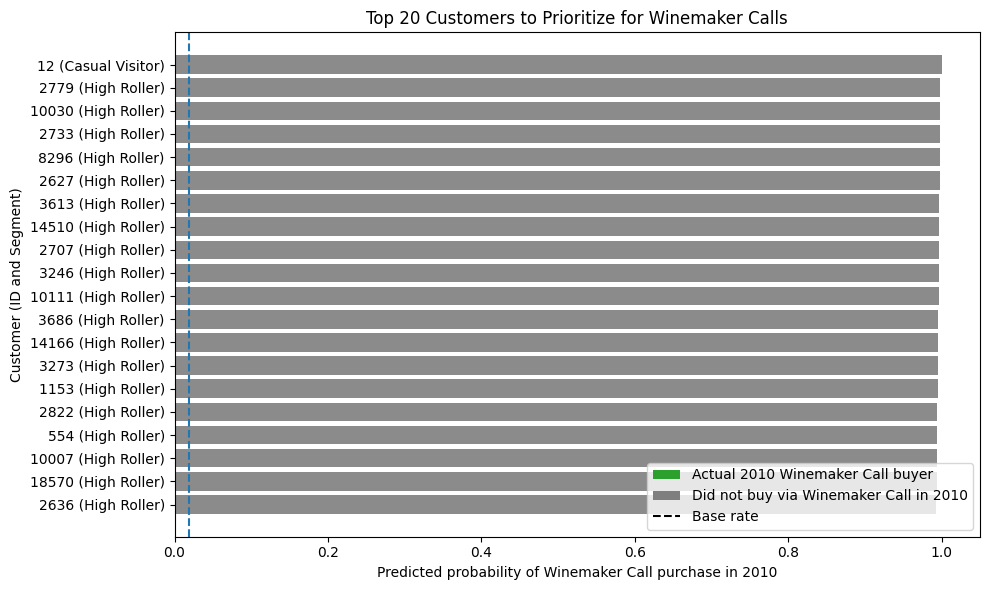

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# For plotting, create a nice label that combines ID and segment
plot_df = top20.copy()
plot_df = plot_df.reset_index()  # brings Customer ID into a column
plot_df["Customer Label"] = plot_df["Customer ID"].astype(str) + " (" + plot_df["Customer Segment"] + ")"

# Sort so the highest probability shows at the top of the chart
plot_df = plot_df.sort_values("proba_win_2010", ascending=True)

# Colors: green if actual 2010 Winemaker Call buyer, gray otherwise
colors = np.where(plot_df["target_win_2010"] == 1, "tab:green", "tab:gray")

# Base rate for reference (same as before, but recompute to be safe)
base_rate = data["target_win_2010"].mean()

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Customer Label"],
    plot_df["proba_win_2010"],
    color=colors,
    alpha=0.9
)

# Vertical line at base rate
plt.axvline(
    x=base_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Base rate ({base_rate:.2%})"
)

plt.xlabel("Predicted probability of Winemaker Call purchase in 2010")
plt.ylabel("Customer (ID and Segment)")
plt.title("Top 20 Customers to Prioritize for Winemaker Calls")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tab:green", label="Actual 2010 Winemaker Call buyer"),
    Patch(facecolor="tab:gray", label="Did not buy via Winemaker Call in 2010")
]
plt.legend(handles=legend_elements + [plt.Line2D([0], [0], color="black", linestyle="--", label="Base rate")],
           loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
# Show Feature Importance (The Coefficients)
# Get feature names after preprocessing
preprocessed_feature_names = clf.named_steps['preprocess'].get_feature_names_out()
coef_df = pd.DataFrame({'Feature': preprocessed_feature_names, 'Coefficient': log_reg.coef_[0]})
print("\nFeature Importance (Log Odds):")
print(coef_df.sort_values(by='Coefficient', ascending=False))


Feature Importance (Log Odds):
                                Feature  Coefficient
12    cat__Customer Segment_High Roller     3.062615
49                        cat__State_NM     1.947475
59                        cat__State_SD     1.373049
6                     num__Email Subscr     1.362548
28                        cat__State_IA     1.338191
..                                  ...          ...
29                        cat__State_ID    -2.445308
23                        cat__State_DE    -2.554363
17                        cat__State_AR    -2.663101
50                        cat__State_NV    -2.839253
13  cat__Customer Segment_Luxury Estate    -5.238115

[71 rows x 2 columns]


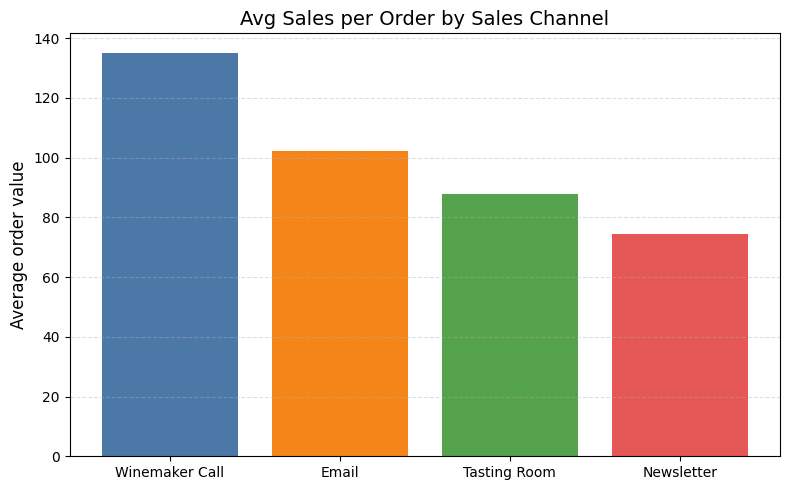

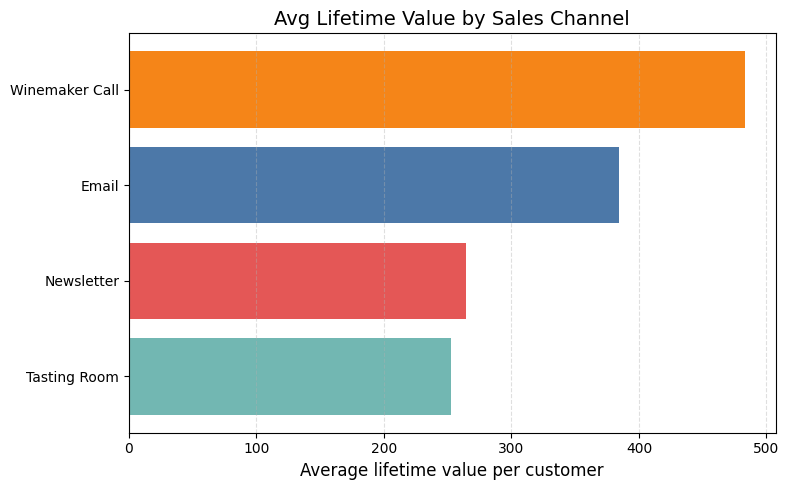

In [ ]:
# --- Avg Sales per Order by Sales Channel (this part was fine) ---

channel_cols = {
    "Winemaker Call": "Winemaker Call Sales",
    "Email": "Email Sales",
    "Tasting Room": "Tasting Room Sales",
    "Newsletter": "Newsletter Sales"
}

avg_sales_per_order = {}
for label, col in channel_cols.items():
    mask = df[col] > 0
    avg_sales_per_order[label] = df.loc[mask, col].mean()

avg_sales_series = pd.Series(avg_sales_per_order)

plt.figure(figsize=(8, 5))
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

plt.bar(avg_sales_series.index, avg_sales_series.values, color=colors)
plt.title("Avg Sales per Order by Sales Channel", fontsize=14)
plt.ylabel("Average order value", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# --- Avg Lifetime Value by Sales Channel (corrected to match your slide) ---

# Total lifetime spend per customer across all channels
cust_total_ltv = df.groupby("Customer ID")["Sale Amount"].sum()

# Per-channel: average total LTV of customers who ever used that channel
channel_ltv = {}
cust_channel_sums = df.groupby("Customer ID")[list(channel_cols.values())].sum()

for label, col in channel_cols.items():
    users = cust_channel_sums[col] > 0          # customers who used this channel
    channel_ltv[label] = cust_total_ltv[users].mean()

channel_ltv_series = pd.Series(channel_ltv)

# Reorder to match your slide order
channel_ltv_plot = channel_ltv_series[["Tasting Room", "Newsletter", "Email", "Winemaker Call"]]

plt.figure(figsize=(8, 5))
colors2 = ["#72B7B2", "#E45756", "#4C78A8", "#F58518"]

plt.barh(channel_ltv_plot.index, channel_ltv_plot.values, color=colors2)
plt.title("Avg Lifetime Value by Sales Channel", fontsize=14)
plt.xlabel("Average lifetime value per customer", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
